In [63]:
# Pour la manipulation de tableaux
import numpy as np
import pandas as pd

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling


# Pour encoder les labels
from tensorflow.keras.utils import to_categorical

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

import itertools


np.random.seed(42)
tf.random.set_seed(42)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


In [64]:
import os
import numpy as np
from keras.utils import load_img, img_to_array

def load_dataset_from_directory(base_dir, img_size, color_mode):
    X = []
    y = []
    class_names = []

    for class_name in os.listdir(base_dir):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        class_names.append(class_name)
        class_index = len(class_names) - 1

        for root, dirs, files in os.walk(class_path):
            for filename in files:
                if filename.lower().endswith((".png", ".jpg", ".jpeg")):
                    file_path = os.path.join(root, filename)

                    img = load_img(file_path, target_size=img_size, color_mode=color_mode)
                    img_array = img_to_array(img)

                    X.append(img_array)
                    y.append(class_index)

    return np.array(X), np.array(y), class_names

In [65]:
chemin_good=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Train"
chemin_test=r"C:\Users\fabbg\Documents\Projet DS\NouvelleArbo\Test"
from tensorflow.keras.preprocessing.image import load_img, img_to_array

train_dir = chemin_good
test_dir  = chemin_test

img_size = (128, 128)   # 
color_mode = "rgb"  # ou "grayscale"

X_train_full, y_train_full, class_names_train = load_dataset_from_directory(train_dir, img_size, color_mode)
X_test_full, y_test_full, class_names_test = load_dataset_from_directory(test_dir, img_size, color_mode)


In [66]:
# Shape de X_train and y_train
print('Shape of X:', X_train_full.shape)
print('Shape of y:', y_train_full.shape)
print('Shape of X_test:', X_test_full.shape)
print('Shape of y_test:', y_test_full.shape)
print("classes train:",class_names_train)
print("classes test:",class_names_test)

Shape of X: (5865, 128, 128, 3)
Shape of y: (5865,)
Shape of X_test: (1725, 128, 128, 3)
Shape of y_test: (1725,)
classes train: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
classes test: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [40]:
# structure du dataset
def load_dataset_structure(root_dir):
    """
    Parcourt le dataset et retourne une liste de dictionnaires :
    [
        {
            'class': 'bottle',
            'subclass': 'broken_large',
            'split': 'test',
            'path': '/.../bottle/test/broken_large/000.png'
        },
        ...
    ]
    """
    data = []

    # Liste des classes (bottle, cable, capsule...)
    classes = sorted(os.listdir(root_dir))

    for class_name in classes:
        class_path = os.path.join(root_dir, class_name)

        # splits : train / test
        for split in ["train", "test"]:
            split_path = os.path.join(class_path, split)
            if not os.path.isdir(split_path):
                continue

            # sous-classes : good, broken_large, contamination...
            subclasses = sorted(os.listdir(split_path))

            for subclass in subclasses:
                subclass_path = os.path.join(split_path, subclass)

                # images
                for fname in os.listdir(subclass_path):
                    if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                        data.append({
                            "class": class_name,
                            "subclass": subclass,
                            "split": split,
                            "path": os.path.join(subclass_path, fname)
                        })

    return data


In [52]:
root = r"C:\Users\fabbg\Documents\Projet DS\mes_images_Train_augmentees"

dataset = load_dataset_structure(root)

print("Nombre total d'images :", len(dataset))

# Afficher ds images au hasrad
num_alea = np.random.randint(0, len(dataset), size=10)

for idx in num_alea:
    item = dataset[idx]
    print(
        "Classe :", item["class"],
        "Sous-classe :", item["subclass"],
        "Split :", item["split"],
        "Path :", item["path"]
    )

    
#Associer les sous_classes    
subclasses_test = [item["subclass"] for item in dataset if item["split"] == "test"]
for i in np.random.randint(1,101,size=10):
    print(
        "Classe :", class_names_train[y_test_full[i]],
        "Sous-classe :", subclasses_test[i]
    )


Nombre total d'images : 7590
Classe : transistor Sous-classe : good Split : train Path : C:\Users\fabbg\Documents\Projet DS\mes_images_Train_augmentees\transistor\train\good\148.png
Classe : tile Sous-classe : good Split : train Path : C:\Users\fabbg\Documents\Projet DS\mes_images_Train_augmentees\tile\train\good\aug_54_092.png
Classe : zipper Sous-classe : good Split : train Path : C:\Users\fabbg\Documents\Projet DS\mes_images_Train_augmentees\zipper\train\good\051.png
Classe : capsule Sous-classe : poke Split : test Path : C:\Users\fabbg\Documents\Projet DS\mes_images_Train_augmentees\capsule\test\poke\004.png
Classe : hazelnut Sous-classe : good Split : train Path : C:\Users\fabbg\Documents\Projet DS\mes_images_Train_augmentees\hazelnut\train\good\041.png
Classe : cable Sous-classe : good Split : train Path : C:\Users\fabbg\Documents\Projet DS\mes_images_Train_augmentees\cable\train\good\aug_19_066.png
Classe : metal_nut Sous-classe : scratch Split : test Path : C:\Users\fabbg\Docum

In [58]:
#Mapping test
mapping_test = defaultdict(set)

for item in dataset:
    if item["split"] == "test":
        mapping_test[item["class"]].add(item["subclass"])

for cls, subs in mapping_test.items():
    print(f"{cls} (test) :")
    for sub in sorted(subs):
        print(f"   - {sub}")


bottle (test) :
   - broken_large
   - broken_small
   - contamination
   - good
cable (test) :
   - bent_wire
   - cable_swap
   - combined
   - cut_inner_insulation
   - cut_outer_insulation
   - good
   - missing_cable
   - missing_wire
   - poke_insulation
capsule (test) :
   - crack
   - faulty_imprint
   - good
   - poke
   - scratch
   - squeeze
carpet (test) :
   - color
   - cut
   - good
   - hole
   - metal_contamination
   - thread
grid (test) :
   - bent
   - broken
   - glue
   - good
   - metal_contamination
   - thread
hazelnut (test) :
   - crack
   - cut
   - good
   - hole
   - print
leather (test) :
   - color
   - cut
   - fold
   - glue
   - good
   - poke
metal_nut (test) :
   - bent
   - color
   - flip
   - good
   - scratch
pill (test) :
   - color
   - combined
   - contamination
   - crack
   - faulty_imprint
   - good
   - pill_type
   - scratch
screw (test) :
   - good
   - manipulated_front
   - scratch_head
   - scratch_neck
   - thread_side
   - thread_

In [59]:
# affichage item
import cv2

def show_item(item):
    img = cv2.imread(item["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"{item['class']} / {item['subclass']} ({item['split']})")
    plt.axis("off")
    plt.show()


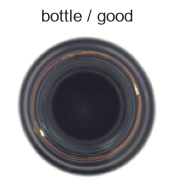

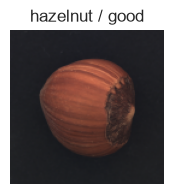

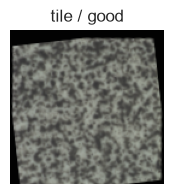

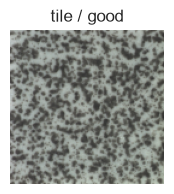

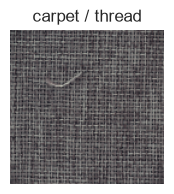

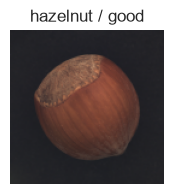

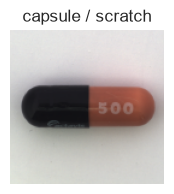

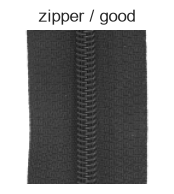

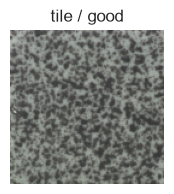

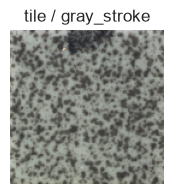

In [60]:
import cv2
import matplotlib.pyplot as plt

num_alea = np.random.randint(0, len(dataset), size=10)

for idx in num_alea:
    item = dataset[idx]
    img = cv2.imread(item["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    plt.title(f"{item['class']} / {item['subclass']}")
    plt.axis("off")
    plt.show()


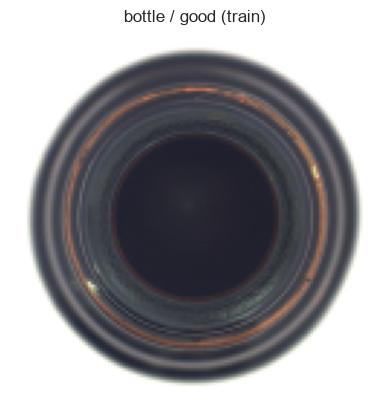

In [61]:
show_item(dataset[12])

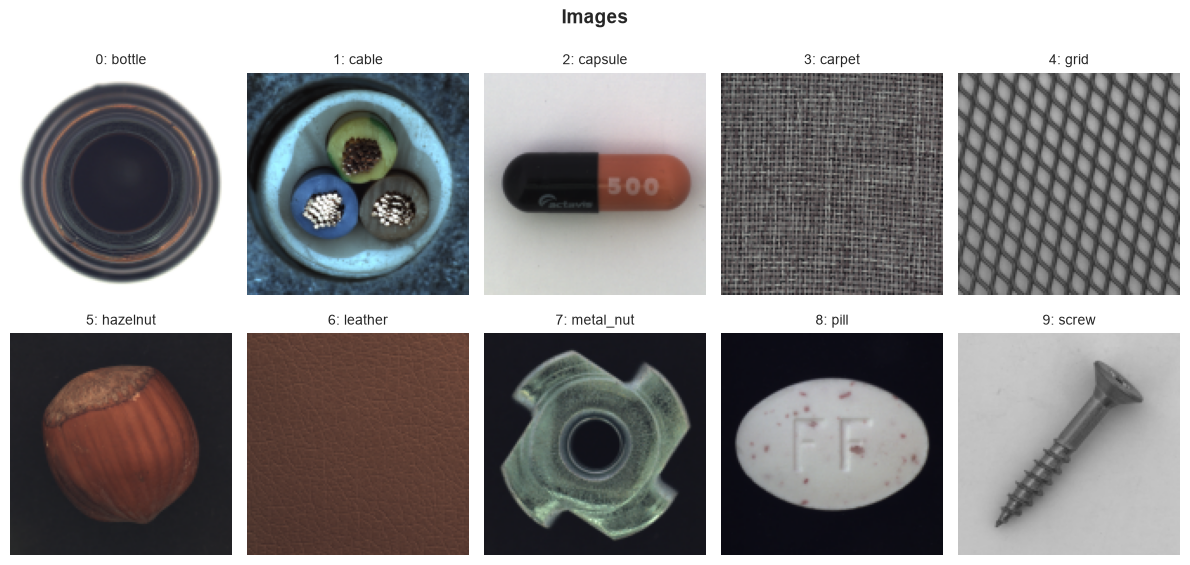

In [9]:
#affichage images par classe
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Images", fontsize=14, fontweight="bold")

for label in range(10):
    ax = axes[label // 5, label % 5]
    idx = np.where(y_train_full == label)[0][0]
    ax.imshow(X_train_full[idx].astype("uint8"))
    ax.set_title(f"{label}: {class_names_train[label]}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [80]:
NORMAL_CLASS = 0  # Images Bottle

# Jeu d'entraînement : uniquement les conformes
mask_train_normal = (y_train_full == NORMAL_CLASS)
X_train = X_train_full[mask_train_normal]
y_train = y_train_full[mask_train_normal]

# Jeu de test : TOUTES les classes
mask_test=(y_test_full == NORMAL_CLASS)
X_test = X_test_full[mask_test]
y_test = y_test_full[mask_test]

# Labels binaires pour l'évaluation
# 0 = normal, 1 = anomalie
#y_test_binary = (y_test != NORMAL_CLASS).astype(int)

y_test_binary = np.array([1 if item["subclass"] != "good" else 0
                          for item in dataset if item["split"] == "test"])



print(f"Entraînement : {X_train.shape[0]} images (uniquement des {class_names_train[NORMAL_CLASS]})")
print(f"Test : {X_test.shape[0]} images (toutes classes)")
print(f"  -  {np.sum(y_test_binary == 0)} normaux ({class_names_test[NORMAL_CLASS]})")
print(f"  -  {np.sum(y_test_binary == 1)} anomalies (autres classes)")

# Entraînement : 6000 images (uniquement des T-shirt/top)
# Test : 10000 images (toutes classes)
#   -  1000 normaux (T-shirt/top)
#   -  9000 anomalies (autres classes)
# Normaliser et aplatir les pixels. Vérifier en affichant la shape de X_train.

# Normalisation [0, 1] et aplatissement
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm  = X_test.astype("float32") / 255.0

X_train_flat = X_train_norm.reshape(-1, 49152)
X_test_flat  = X_test_norm.reshape(-1, 49152)

print(f"Shape X_train : {X_train_flat.shape}")



Entraînement : 391 images (uniquement des bottle)
Test : 83 images (toutes classes)
  -  467 normaux (bottle)
  -  1258 anomalies (autres classes)
Shape X_train : (391, 49152)


In [32]:
print(y_test)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [68]:
from tensorflow.keras import layers
# Encodeur :
encoder_input = keras.Input(shape=(49152,), name="input")
x = layers.Dense(1024, activation="relu", name="enc_dense1")(encoder_input)
x = layers.Dense(512, activation="relu", name="enc_dense2")(x)
latent = layers.Dense(128, activation="relu", name="bottleneck")(x)

encoder = Model(encoder_input, latent, name="encodeur")

# Décodeur :
decoder_input = keras.Input(shape=(128,), name="latent_input")
x = layers.Dense(512, activation="relu", name="dec_dense2")(decoder_input)
x = layers.Dense(1024, activation="relu", name="dec_dense1")(x)
decoder_output = layers.Dense(49152, activation="sigmoid", name="output")(x)

decoder = Model(decoder_input, decoder_output, name="decodeur")

# Auto-encodeur complet :
autoencoder_output = decoder(encoder(encoder_input))
autoencoder = Model(encoder_input, autoencoder_output, name="auto_encodeur")

autoencoder.summary()


Model: "auto_encodeur"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 49152)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encodeur (Functional)                │ (None, 128)                 │      50,923,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decodeur (Functional)                │ (None, 49152)               │      50,972,160 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,895,296 (388.70 MB)

 Trainable params: 101,895,296 (388.70 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

history = autoencoder.fit(
    X_train_flat, X_train_flat,  # le modèle ne voit QUE la classe normale
    epochs=50,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,  # 20% des images normales
    verbose=1
)


Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - loss: 0.6876 - val_loss: 0.7677
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.5796 - val_loss: 0.5980
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4926 - val_loss: 0.6230
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4595 - val_loss: 0.5799
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4491 - val_loss: 0.5754
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4420 - val_loss: 0.5803
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4398 - val_loss: 0.5667
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4340 - val_loss: 0.5661
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4325 - val_loss: 0.5643
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4301 - val_loss: 0.5610
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4277 - val_loss: 0.5474
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 0.4223 - val_loss: 0.5345
Epoch 13/50
2/2 ━━━━━━━━━

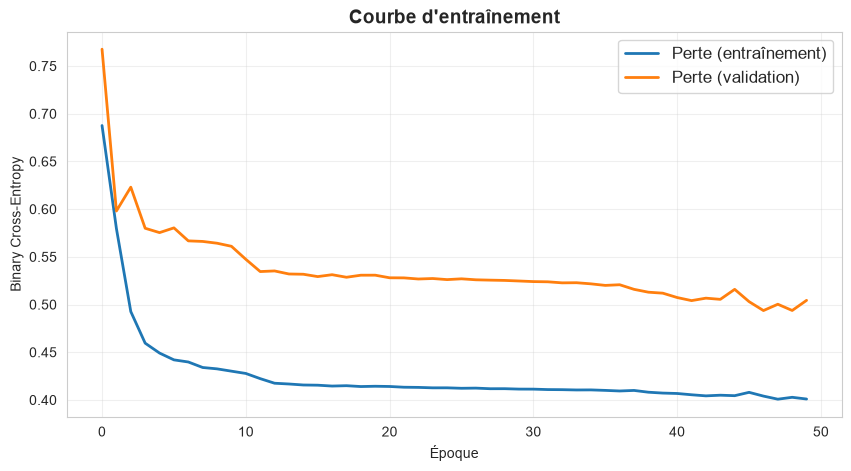

In [70]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Perte (entraînement)", linewidth=2)
plt.plot(history.history["val_loss"], label="Perte (validation)", linewidth=2)
plt.xlabel("Époque")
plt.ylabel("Binary Cross-Entropy")
plt.title("Courbe d'entraînement", fontsize=14, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


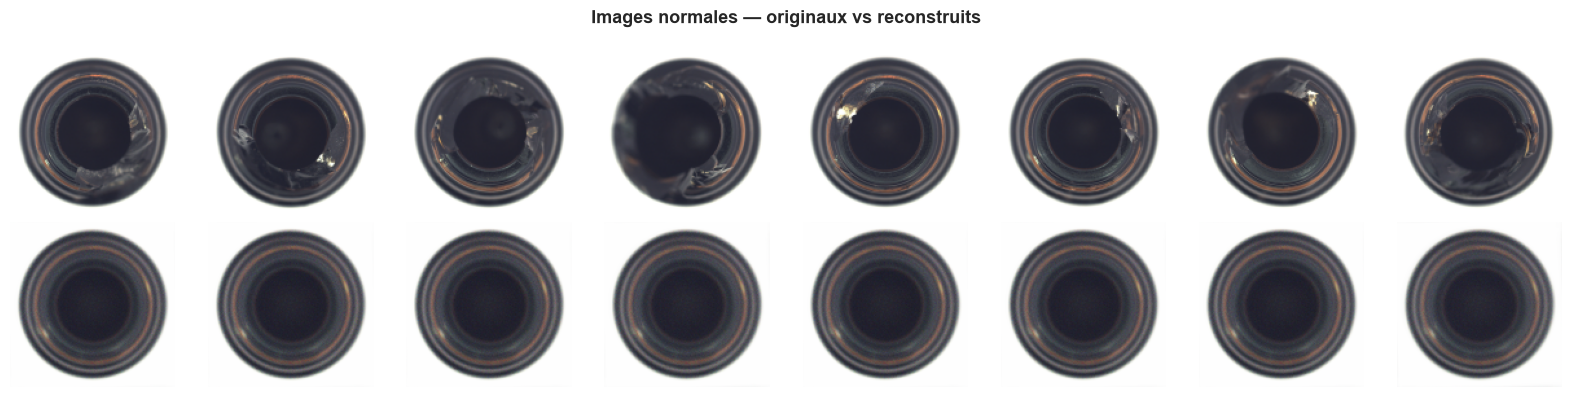

In [71]:
# Classe normale uniquement !
idx_normal = np.where(y_test == NORMAL_CLASS)[0][:8]
X_normal = X_test_flat[idx_normal]
X_normal_reconstructed = autoencoder.predict(X_normal, verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle("Images normales — originaux vs reconstruits", fontsize=13, fontweight="bold")

for i in range(8):
    axes[0, i].imshow(X_normal[i].reshape(128, 128,3))
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("Original", fontsize=11)
    
    axes[1, i].imshow(X_normal_reconstructed[i].reshape(128, 128,3))
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_ylabel("Reconstruit", fontsize=11)

plt.tight_layout()
plt.show()


In [20]:
print(class_names_test)

['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


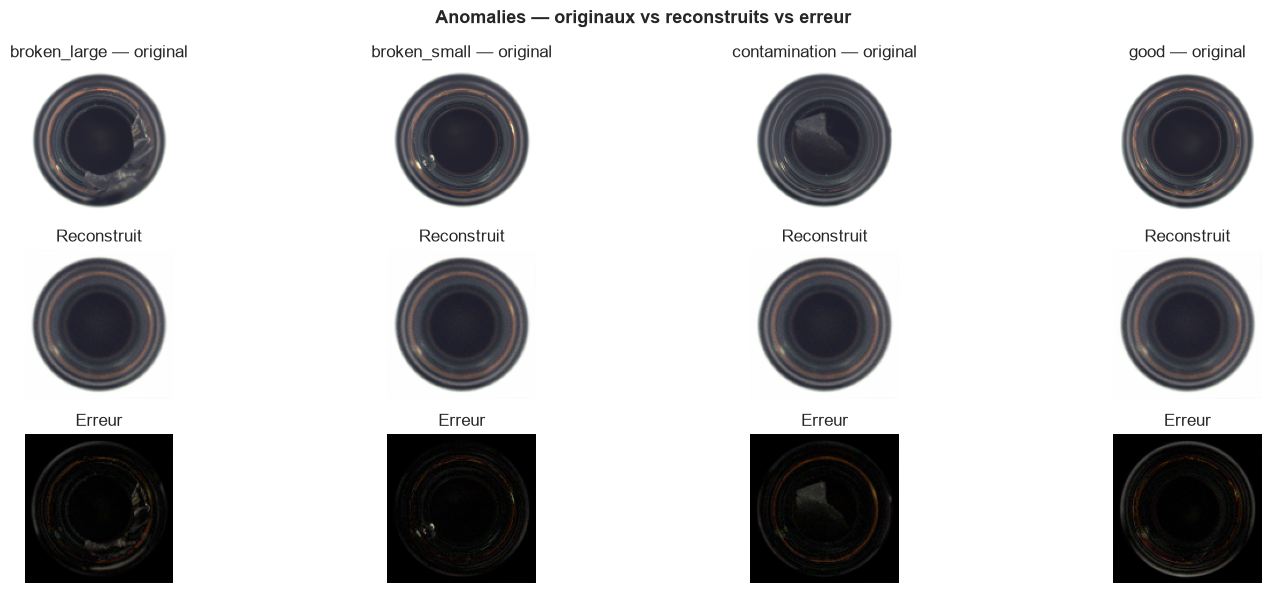

In [78]:
# Sélection de quelques anomalies
anomaly_classes = ["broken_large","broken_small","contamination","good"]  # 
fig, axes = plt.subplots(3, len(anomaly_classes), figsize=(16, 6))
fig.suptitle("Anomalies — originaux vs reconstruits vs erreur", fontsize=13, fontweight="bold")

for j, cls in enumerate(anomaly_classes):

    # 1. Trouver une image de la sous-classe
    item = next(d for d in dataset if d["subclass"] == cls and d["split"] == "test")

    # 2. Charger l'image
    img = cv2.imread(item["path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.astype("float32") / 255.0
    original_flat = original.reshape(-1)

    # 3. Reconstruction
    reconstructed = autoencoder.predict(original_flat.reshape(1, -1), verbose=0)[0]
    error_map = np.abs(original_flat - reconstructed)

    # 4. Affichage
    axes[0, j].imshow(original)
    axes[0, j].set_title(f"{cls} — original")
    axes[0, j].axis("off")

    axes[1, j].imshow(reconstructed.reshape(original.shape))
    axes[1, j].set_title("Reconstruit")
    axes[1, j].axis("off")

    axes[2, j].imshow(error_map.reshape(original.shape), cmap="hot")
    axes[2, j].set_title("Erreur")
    axes[2, j].axis("off")

plt.tight_layout()
plt.show()



In [81]:
# Reconstruction de toutes les images de test
X_test_reconstructed = autoencoder.predict(X_test_flat, verbose=0)

# Score d'anomalie = MSE par image
reconstruction_errors = np.mean((X_test_flat - X_test_reconstructed) ** 2, axis=1)

print(f"Erreur moyenne (normaux)   : {reconstruction_errors[y_test_binary == 0].mean():.6f}")
print(f"Erreur moyenne (anomalies) : {reconstruction_errors[y_test_binary == 1].mean():.6f}")
print(f"Ratio : {reconstruction_errors[y_test_binary == 1].mean() / reconstruction_errors[y_test_binary == 0].mean():.1f}x")


IndexError: boolean index did not match indexed array along axis 0; size of axis is 83 but size of corresponding boolean axis is 1725

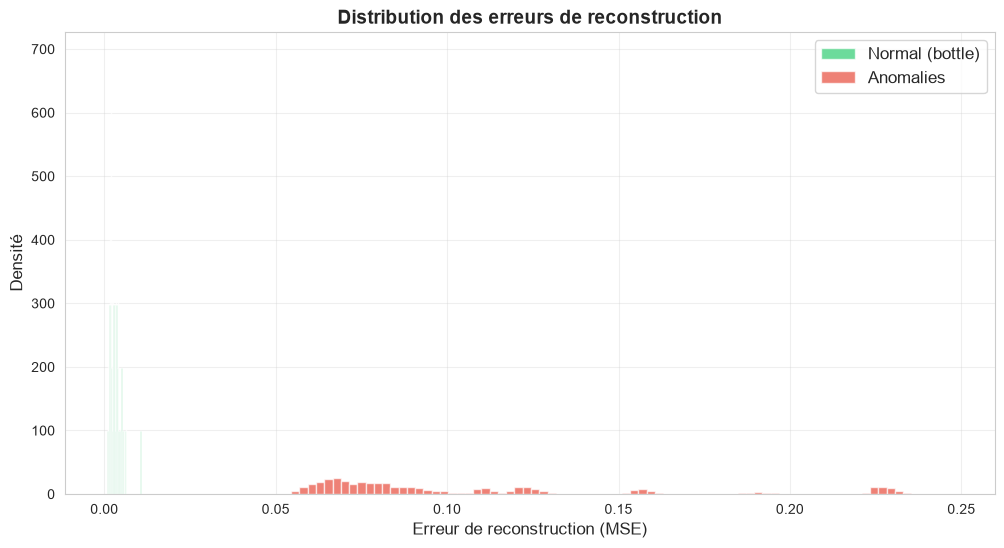

In [25]:
plt.figure(figsize=(12, 6))

plt.hist(reconstruction_errors[y_test_binary == 0], bins=80, alpha=0.7, 
         label=f"Normal ({class_names_test[NORMAL_CLASS]})", color="#2ecc71", density=True)
plt.hist(reconstruction_errors[y_test_binary == 1], bins=80, alpha=0.7, 
         label="Anomalies", color="#e74c3c", density=True)

plt.xlabel("Erreur de reconstruction (MSE)", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.title("Distribution des erreurs de reconstruction", fontsize=14, fontweight="bold")
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()


In [26]:
# Erreur de reconstruction sur les données d'entraînement (normales)
X_train_reconstructed = autoencoder.predict(X_train_flat, verbose=0)
train_errors = np.mean((X_train_flat - X_train_reconstructed) ** 2, axis=1)

# Seuil : percentile 95 des erreurs normales
threshold = np.percentile(train_errors, 95)

print(f"Seuil (percentile 95) : {threshold:.6f}")
print(f"Erreurs d'entraînement — min: {train_errors.min():.6f}, max: {train_errors.max():.6f}, moyenne: {train_errors.mean():.6f}")


Seuil (percentile 95) : 0.047974
Erreurs d'entraînement — min: 0.000608, max: 0.073991, moyenne: 0.013443


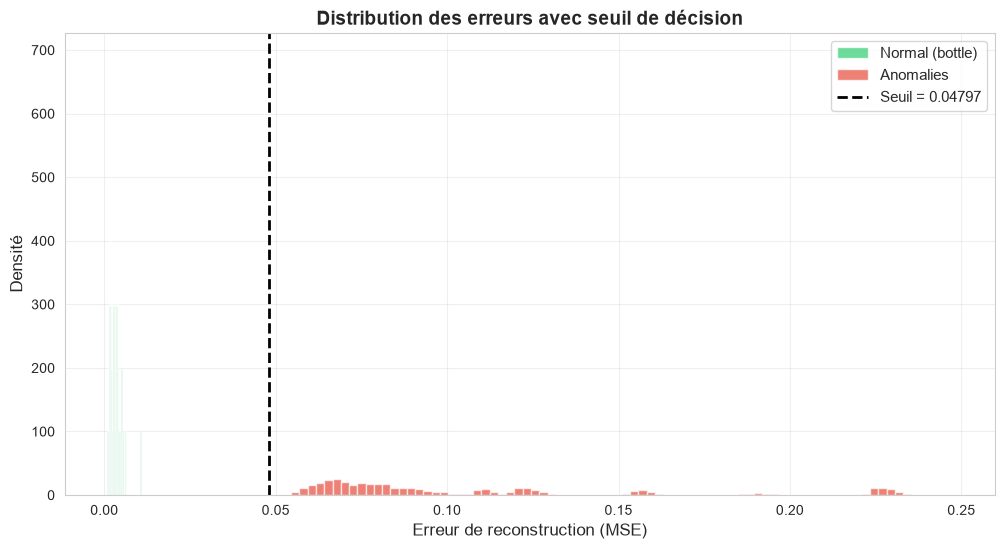

In [28]:
# Visualisation du seuil sur la distribution
plt.figure(figsize=(12, 6))

plt.hist(reconstruction_errors[y_test_binary == 0], bins=80, alpha=0.7, 
         label=f"Normal ({class_names_test[NORMAL_CLASS]})", color="#2ecc71", density=True)
plt.hist(reconstruction_errors[y_test_binary == 1], bins=80, alpha=0.7, 
         label="Anomalies", color="#e74c3c", density=True)
plt.axvline(x=threshold, color="black", linestyle="--", linewidth=2, 
            label=f"Seuil = {threshold:.5f}")

plt.xlabel("Erreur de reconstruction (MSE)", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.title("Distribution des erreurs avec seuil de décision", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()


In [29]:
#Evaluation
y_pred = (reconstruction_errors > threshold).astype(int)

print(classification_report(
    y_test_binary, y_pred, 
    target_names=["Normal", "Anomalie"]
))


              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        83
    Anomalie       1.00      1.00      1.00      1642

    accuracy                           1.00      1725
   macro avg       1.00      1.00      1.00      1725
weighted avg       1.00      1.00      1.00      1725



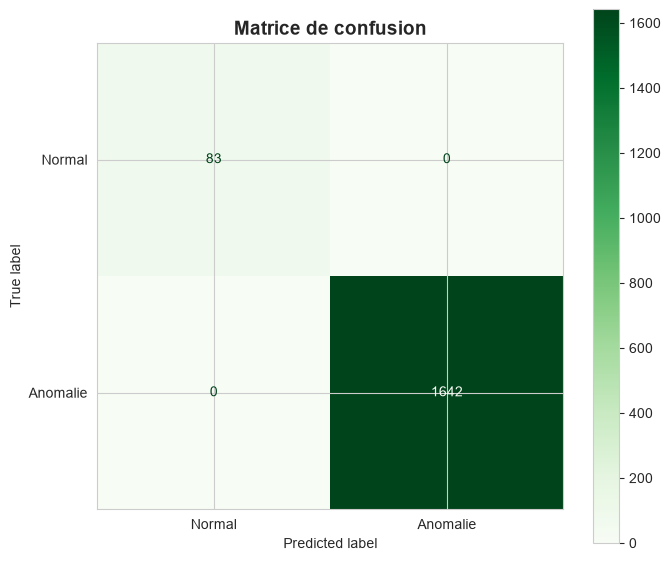

Faux positifs (normaux classés anomalie) : 0
Faux négatifs (anomalies non détectées)  : 0


In [30]:
# Matrice de confusion
cm = confusion_matrix(y_test_binary, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Anomalie"])
disp.plot(ax=ax, cmap="Greens", values_format="d")
ax.set_title("Matrice de confusion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Faux positifs (normaux classés anomalie) : {fp}")
print(f"Faux négatifs (anomalies non détectées)  : {fn}")
